In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

In [ ]:
from google.colab import files

uploaded = files.upload()

Saving 3b01bcb8-0b14-4abf-b6f2-c1bfd384ba69.csv to 3b01bcb8-0b14-4abf-b6f2-c1bfd384ba69.csv


In [ ]:
file_name = "3b01bcb8-0b14-4abf-b6f2-c1bfd384ba69.csv"

df = pd.read_csv(file_name)

df.head()

,country,state,city,station,last_update,latitude,longitude,pollutant_id,pollutant_min,pollutant_max,pollutant_avg
0,India,Chandigarh,Chandigarh,"Sector-53, Chandigarh - CPCC",23-08-2026 10:00:00,30.719859,76.738637,CO,27.0,40.0,33.0
1,India,Chandigarh,Chandigarh,"Sector-53, Chandigarh - CPCC",23-08-2026 10:00:00,30.719859,76.738637,OZONE,5.0,11.0,8.0
2,India,Chhattisgarh,Bhilai,"32Bungalows, Bhilai - CECB",23-08-2026 10:00:00,21.194815,81.314770,NH3,4.0,5.0,5.0
3,India,Chhattisgarh,Bhilai,"32Bungalows, Bhilai - CECB",23-08-2026 10:00:00,21.194815,81.314770,CO,10.0,14.0,13.0
4,India,Chhattisgarh,Bhilai,"Hathkhoj, Bhilai - CECB",23-08-2026 10:00:00,21.224231,81.408350,OZONE,4.0,7.0,5.0


In [ ]:
df.shape

(3486, 11)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3486 entries, 0 to 3485
Data columns (total 11 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   country        3486 non-null   object 
 1   state          3486 non-null   object 
 2   city           3486 non-null   object 
 3   station        3486 non-null   object 
 4   last_update    3486 non-null   object 
 5   latitude       3486 non-null   float64
 6   longitude      3486 non-null   float64
 7   pollutant_id   3486 non-null   object 
 8   pollutant_min  3213 non-null   float64
 9   pollutant_max  3213 non-null   float64
 10  pollutant_avg  3213 non-null   float64
dtypes: float64(5), object(6)
memory usage: 299.7+ KB


In [ ]:
df.describe(include="all")

,country,state,city,station,last_update,latitude,longitude,pollutant_id,pollutant_min,pollutant_max,pollutant_avg
count,3486,3486,3486,3486,3486,3486.000000,3486.000000,3486,3213.000000,3213.000000,3213.000000
unique,1,31,263,498,1,NaN,NaN,7,NaN,NaN,NaN
top,India,Maharashtra,Delhi,"Chitragupta Nagar, Siwan - BSPCB",23-08-2026 10:00:00,NaN,NaN,CO,NaN,NaN,NaN
freq,3486,602,308,7,3486,NaN,NaN,498,NaN,NaN,NaN
mean,NaN,NaN,NaN,NaN,NaN,23.414101,78.511381,NaN,17.600062,43.365079,27.697168
std,NaN,NaN,NaN,NaN,NaN,5.146117,4.894763,NaN,17.489110,53.930934,27.112080
min,NaN,NaN,NaN,NaN,NaN,8.514909,70.776774,NaN,0.000000,0.000000,0.000000
25%,NaN,NaN,NaN,NaN,NaN,19.230757,75.386577,NaN,5.000000,11.000000,8.000000
50%,NaN,NaN,NaN,NaN,NaN,23.939892,77.273621,NaN,12.000000,26.000000,19.000000
75%,NaN,NaN,NaN,NaN,NaN,28.206800,80.322986,NaN,25.000000,56.000000,39.000000


In [ ]:
# Check unique pollutants monitored across all stations
print("--- Pollutant Breakdown ---")
print(df["pollutant_id"].value_counts())

print("\n--- Missing Values Breakdown ---")
print(df.isnull().sum())

--- Pollutant Breakdown ---
pollutant_id
CO       498
OZONE    498
NH3      498
PM2.5    498
PM10     498
NO2      498
SO2      498
Name: count, dtype: int64

--- Missing Values Breakdown ---
country            0
state              0
city               0
station            0
last_update        0
latitude           0
longitude          0
pollutant_id       0
pollutant_min    273
pollutant_max    273
pollutant_avg    273
dtype: int64


In [ ]:
# Pivot dataset: Station metadata as index, pollutants as columns
df_wide = df.pivot(
    index=['state', 'city', 'station', 'latitude', 'longitude', 'last_update'],
    columns='pollutant_id',
    values='pollutant_avg'
).reset_index()

# Flatten column names
df_wide.columns.name = None

# Preview reshaped data
print(f"New Shape: {df_wide.shape}")
df_wide.head()

New Shape: (498, 13)


,state,city,station,latitude,longitude,last_update,CO,NH3,NO2,OZONE,PM10,PM2.5,SO2
0,Andhra Pradesh,Anantapur,"Gulzarpet, Anantapur - APPCB",14.675886,77.593027,23-08-2026 10:00:00,31.0,5.0,21.0,20.0,70.0,70.0,14.0
1,Andhra Pradesh,Chittoor,"Gangineni Cheruvu, Chittoor - APPCB",13.204880,79.097889,23-08-2026 10:00:00,21.0,6.0,28.0,29.0,73.0,75.0,22.0
2,Andhra Pradesh,Eluru,"District Court, Eluru - APPCB",16.711754,81.092095,23-08-2026 10:00:00,10.0,4.0,18.0,10.0,53.0,51.0,9.0
3,Andhra Pradesh,Guntur,"Rajendra Nagar North, Guntur - APPCB",16.316553,80.413302,23-08-2026 10:00:00,19.0,7.0,33.0,22.0,67.0,58.0,11.0
4,Andhra Pradesh,Kadapa,"Yerramukkapalli, Kadapa - APPCB",14.465052,78.824187,23-08-2026 10:00:00,42.0,2.0,24.0,29.0,44.0,46.0,17.0


In [ ]:
# Convert last_update to datetime
df_wide['last_update'] = pd.to_datetime(df_wide['last_update'], errors='coerce')

# Check missing values per pollutant column in the reshaped data
print("--- Missing Values Per Pollutant (Station Count: 498) ---")
print(df_wide[['CO', 'NH3', 'NO2', 'OZONE', 'PM10', 'PM2.5', 'SO2']].isnull().sum())

# Display data types
print("\n--- Field Types ---")
print(df_wide.dtypes)

--- Missing Values Per Pollutant (Station Count: 498) ---
CO       22
NH3      68
NO2      19
OZONE    37
PM10     36
PM2.5    36
SO2      55
dtype: int64

--- Field Types ---
state                  object
city                   object
station                object
latitude              float64
longitude             float64
last_update    datetime64[ns]
CO                    float64
NH3                   float64
NO2                   float64
OZONE                 float64
PM10                  float64
PM2.5                 float64
SO2                   float64
dtype: object


/tmp/ipykernel_659/905061294.py:2: UserWarning: Parsing dates in %d-%m-%Y %H:%M:%S format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df_wide['last_update'] = pd.to_datetime(df_wide['last_update'], errors='coerce')


In [ ]:
# Clean date parsing with dayfirst specified
df_wide['last_update'] = pd.to_datetime(df_wide['last_update'], dayfirst=True, errors='coerce')

# Statistical summary of pollutants
pollutants = ['CO', 'NH3', 'NO2', 'OZONE', 'PM10', 'PM2.5', 'SO2']
df_wide[pollutants].describe().T[['mean', 'std', 'min', '50%', 'max']]

,mean,std,min,50%,max
CO,29.703782,20.138532,2.0,25.0,187.0
NH3,4.725581,3.881586,0.0,4.0,34.0
NO2,19.425887,15.646000,0.0,16.0,120.0
OZONE,18.138829,15.819987,1.0,15.0,217.0
PM10,62.833333,30.917431,9.0,57.5,209.0
PM2.5,43.965368,26.367643,2.0,38.0,224.0
SO2,13.119639,13.294834,0.0,9.0,86.0


In [ ]:
# Compute pairwise Pearson correlation (ignoring NaNs pairwise)
corr_matrix = df_wide[pollutants].corr()

# Format as a clean table rounded to 2 decimal places
corr_matrix.round(2)

,CO,NH3,NO2,OZONE,PM10,PM2.5,SO2
CO,1.00,0.13,0.13,0.08,0.21,0.21,0.09
NH3,0.13,1.00,0.32,0.08,0.20,0.18,0.00
NO2,0.13,0.32,1.00,0.15,0.26,0.21,0.11
OZONE,0.08,0.08,0.15,1.00,0.07,0.05,0.09
PM10,0.21,0.20,0.26,0.07,1.00,0.70,0.08
PM2.5,0.21,0.18,0.21,0.05,0.70,1.00,0.09
SO2,0.09,0.00,0.11,0.09,0.08,0.09,1.00


In [ ]:
# Save wide-format cleaned snapshot to CSV
df_wide.to_csv("cpcb_realtime_aqi_clean.csv", index=False)
print("Clean dataset successfully saved as cpcb_realtime_aqi_clean.csv!")

Clean dataset successfully saved as cpcb_realtime_aqi_clean.csv!


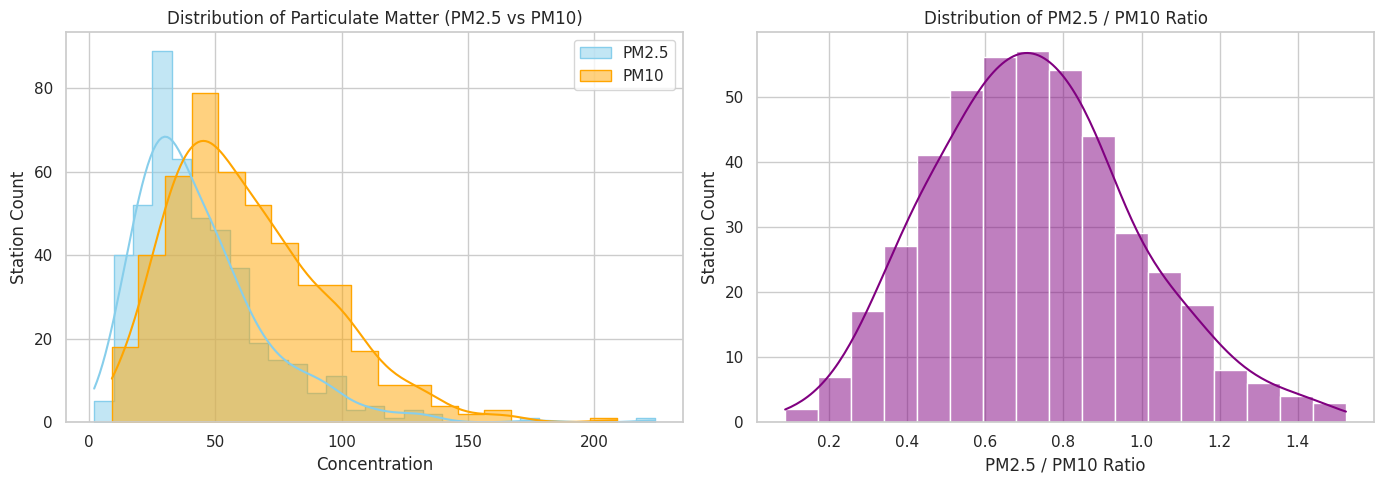

--- PM2.5 / PM10 Ratio Summary Statistics ---
mean    0.725884
50%     0.714286
min     0.086957
max     1.523810
Name: PM_ratio, dtype: float64


In [ ]:
import seaborn as sns
sns.set_theme(style="whitegrid")

# Create figure with 2 subplots
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 1. Distribution of PM2.5 and PM10
sns.histplot(df_wide['PM2.5'], color='skyblue', label='PM2.5', kde=True, ax=axes[0], element="step")
sns.histplot(df_wide['PM10'], color='orange', label='PM10', kde=True, ax=axes[0], element="step")
axes[0].set_title('Distribution of Particulate Matter (PM2.5 vs PM10)')
axes[0].set_xlabel('Concentration')
axes[0].set_ylabel('Station Count')
axes[0].legend()

# 2. PM2.5 to PM10 Ratio Distribution
df_wide['PM_ratio'] = df_wide['PM2.5'] / df_wide['PM10']

sns.histplot(df_wide['PM_ratio'].dropna(), color='purple', kde=True, ax=axes[1])
axes[1].set_title('Distribution of PM2.5 / PM10 Ratio')
axes[1].set_xlabel('PM2.5 / PM10 Ratio')
axes[1].set_ylabel('Station Count')

plt.tight_layout()
plt.show()

# Display summary statistics for PM ratio
print("--- PM2.5 / PM10 Ratio Summary Statistics ---")
print(df_wide['PM_ratio'].describe()[['mean', '50%', 'min', 'max']])

/tmp/ipykernel_659/729220036.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_cities, x='PM2.5', y='city', palette='Reds_r')


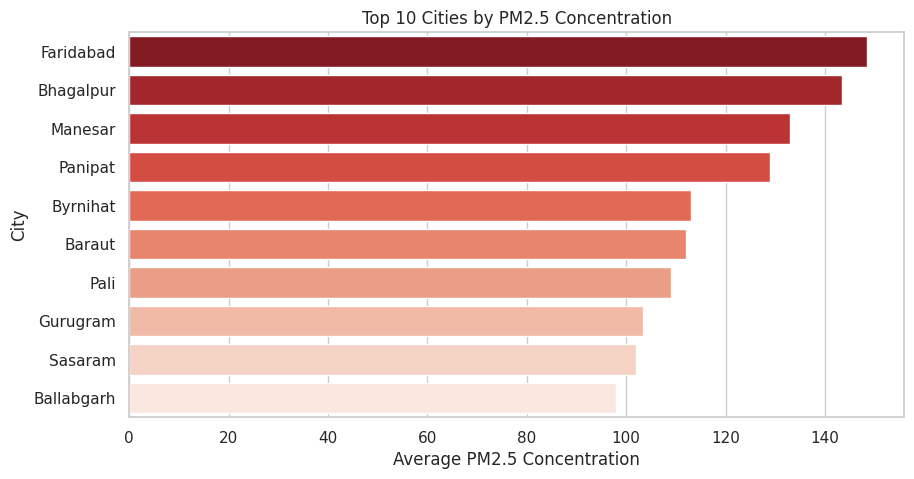

--- Top 10 Cities by PM2.5 ---
         city       PM2.5
0   Faridabad  148.500000
1   Bhagalpur  143.500000
2     Manesar  133.000000
3     Panipat  129.000000
4    Byrnihat  113.000000
5      Baraut  112.000000
6        Pali  109.000000
7    Gurugram  103.333333
8     Sasaram  102.000000
9  Ballabgarh   98.000000


In [ ]:
# Top 10 cities by mean PM2.5 concentration
top_cities = df_wide.groupby('city')['PM2.5'].mean().nlargest(10).reset_index()

# Plot Top 10 Cities
plt.figure(figsize=(10, 5))
sns.barplot(data=top_cities, x='PM2.5', y='city', palette='Reds_r')
plt.title('Top 10 Cities by PM2.5 Concentration')
plt.xlabel('Average PM2.5 Concentration')
plt.ylabel('City')
plt.show()

print("--- Top 10 Cities by PM2.5 ---")
print(top_cities)

In [ ]:
import scipy.stats as stats

# Categorize major states into geographical regions
region_map = {
    'Delhi': 'North', 'Haryana': 'North', 'Punjab': 'North', 'Uttar Pradesh': 'North', 'Rajasthan': 'North',
    'Maharashtra': 'West', 'Gujarat': 'West',
    'Tamil Nadu': 'South', 'Karnataka': 'South', 'Kerala': 'South', 'Telangana': 'South', 'Andhra Pradesh': 'South'
}

df_wide['region'] = df_wide['state'].map(region_map)

# Extract non-null PM2.5 concentrations by region
north_pm = df_wide[df_wide['region'] == 'North']['PM2.5'].dropna()
west_pm = df_wide[df_wide['region'] == 'West']['PM2.5'].dropna()
south_pm = df_wide[df_wide['region'] == 'South']['PM2.5'].dropna()

# One-Way ANOVA (Parametric)
f_stat, p_val_anova = stats.f_oneway(north_pm, west_pm, south_pm)

# Kruskal-Wallis Test (Non-Parametric alternative for skewed distributions)
h_stat, p_val_kruskal = stats.kruskal(north_pm, west_pm, south_pm)

print(f"--- Hypothesis Testing Results (PM2.5 across North, West, South) ---")
print(f"One-Way ANOVA F-Statistic: {f_stat:.4f} | p-value: {p_val_anova:.4e}")
print(f"Kruskal-Wallis H-Statistic: {h_stat:.4f} | p-value: {p_val_kruskal:.4e}")

if p_val_kruskal < 0.05:
    print("\nResult: Reject the Null Hypothesis (H0) at alpha = 0.05.")
    print("Conclusion: There is a statistically significant difference in PM2.5 levels across Indian regions.")
else:
    print("\nResult: Fail to reject the Null Hypothesis (H0).")

--- Hypothesis Testing Results (PM2.5 across North, West, South) ---
One-Way ANOVA F-Statistic: 36.2526 | p-value: 5.3042e-15
Kruskal-Wallis H-Statistic: 69.5279 | p-value: 7.9839e-16

Result: Reject the Null Hypothesis (H0) at alpha = 0.05.
Conclusion: There is a statistically significant difference in PM2.5 levels across Indian regions.


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score

# Define features (gaseous pollutants + coarse particulates) and target variable
features = ['CO', 'NH3', 'NO2', 'OZONE', 'PM10', 'SO2']
target = 'PM2.5'

# Drop rows where target or features are missing for modeling
model_df = df_wide.dropna(subset=features + [target])

X = model_df[features]
y = model_df[target]

# Train-Test Split (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train Random Forest Regressor
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

# Evaluate predictions (using root_mean_squared_error)
y_pred = rf_model.predict(X_test)
rmse = mean_squared_error(y_test, y_pred) ** 0.5
r2 = r2_score(y_test, y_pred)

print(f"--- Model Evaluation (Random Forest Regressor) ---")
print(f"Root Mean Squared Error (RMSE): {rmse:.2f} µg/m³")
print(f"Coefficient of Determination (R² Score): {r2:.4f}")

# Feature Importance
importances = pd.Series(rf_model.feature_importances_, index=features).sort_values(ascending=False)
print("\n--- Feature Importance ---")
print(importances.round(4))

--- Model Evaluation (Random Forest Regressor) ---
Root Mean Squared Error (RMSE): 26.81 µg/m³
Coefficient of Determination (R² Score): 0.3761

--- Feature Importance ---
PM10     0.5936
CO       0.1108
SO2      0.0900
NO2      0.0795
OZONE    0.0784
NH3      0.0477
dtype: float64
